In [1]:
!pip install cvlib

In [2]:
!pip install tensorflow

  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl (2.9 MB)
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [1]:
import cvlib as cv # 얼굴 탐지하는 기능(도구)
import cv2 
import matplotlib.pyplot as plt

C:\Users\SMHRD\AppData\Local\anaconda3\Lib\site-packages\cvlib\face_detection.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename, Requirement


In [4]:
!pip install --upgrade h5py

  Using cached h5py-3.16.0-cp313-cp313-win_amd64.whl.metadata (3.1 kB)
Using cached h5py-3.16.0-cp313-cp313-win_amd64.whl (3.2 MB)
  Attempting uninstall: h5py
    Found existing installation: h5py 3.14.0
    Uninstalling h5py-3.14.0:
      Successfully uninstalled h5py-3.14.0


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires h5py<3.15.0,>=3.11.0, but you have h5py 3.16.0 which is incompatible.


### 이미지에서 얼굴 탐지

In [13]:
img = cv2.imread('./data/TEAM3.png')

faces, conf = cv.detect_face(img)
print(faces) #좌상단, 우하단 좌표
print(conf)  # 정확도(사람 얼굴이 맞을 확률)




[[np.int64(300), np.int64(186), np.int64(422), np.int64(337)], [np.int64(-2), np.int64(127), np.int64(180), np.int64(386)], [np.int64(506), np.int64(106), np.int64(637), np.int64(286)]]
[np.float32(0.9994419), np.float32(0.9966961), np.float32(0.99392575)]


In [14]:
cv.detect_face(img)

([[np.int64(300), np.int64(186), np.int64(422), np.int64(337)],
  [np.int64(-2), np.int64(127), np.int64(180), np.int64(386)],
  [np.int64(506), np.int64(106), np.int64(637), np.int64(286)]],
 [np.float32(0.9994419), np.float32(0.9966961), np.float32(0.99392575)])

In [17]:
cv2.imshow('TEAM3', img)

cv2.waitKey(0)

cv2.destroyAllWindows()

In [22]:
# 얼굴 영역 부분 사각형 도형 출력하기

import numpy as np

img_bg = np.zeros((480,640,3)) # 해당 크기의 배열 생성 후 0으로 채우기

# 행, 열, 채널 -> 높이(y축), 너비(x축), rgb

line_color = [0,255,0]

line_thick = 4

cv2.rectangle(img_bg, (0,240),(240,480), line_color, line_thick)
# 이미지 ,  좌상단(x,y) , 우하단(x2,y2) , 색상 ,      두께

cv2.rectangle(img_bg, (360,240),(600,480),line_color, cv2.FILLED) # 속이 꽉찬 사각형

cv2.imshow('img', img_bg)

cv2.waitKey(0)
cv2.destroyAllWindows()


In [27]:
# 0번째 사람의 정보 접근

print(faces[0])

print('좌상단좌표 :', (faces[0][0], faces[0][1]))
print('우하단좌표 :', (faces[0][2], faces[0][3]))

[np.int64(300), np.int64(186), np.int64(422), np.int64(337)]
좌상단좌표 : (np.int64(300), np.int64(186))
우하단좌표 : (np.int64(422), np.int64(337))


In [18]:
img = cv2.imread('./data/TEAM3.png')

faces, conf = cv.detect_face(img)

color = [0,255,255] 
line_th = 3

#여러명(3명)의 얼굴에 사각형 및 텍스트 추가

for i in range(len(faces)):
    # 텍스트(정확도) 출력 : 이미지 , 텍스트, 좌표, 글꼴, 글씨크기, 색깔, 두께
    cv2.putText(img, f'{conf[i]:.3f}',(faces[i][0],faces[i][1]-10), cv2.FONT_HERSHEY_PLAIN, 2, color, line_th)
    #사각형 그리기
    cv2.rectangle(img, (faces[i][0],faces[i][1]),(faces[i][2], faces[i][3]), color, line_th)

cv2.imshow('img',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [25]:
img = cv2.imread('./data/TEAM3.png')

faces, conf = cv.detect_face(img)

color = [0,255,255] 
line_th = 3

#여러명(3명)의 얼굴에 사각형 및 텍스트 추가


# zip 함수 : 여러개의 반복가능한 객체를 같은 위치끼리 묶어주는 함수
for (x,y,x2,y2,), c in zip(faces, conf):
    cv2.putText(img, f'{c:.2f}',(x,y-10),cv2.FONT_HERSHEY_PLAIN, 2, color, 1)

    cv2.rectangle(img, (x,y), (x2,y2), color, line_th)
    
cv2.imshow('img',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

- 카메라에서 얼굴 탐지 출력하기

In [28]:
# 얼굴인식이 안됐을때, 에러가 발생하는 경우 존재
# 카메라 읽도록 재실행 연결
# 인식이 안될 경우는 카메라 꺼지도록 설정
# try-except : 예외처리

try:
    print(dfafadsfasdf) # 실행시도
except:
    print('선언되지 않은 변수입니다.')

선언되지 않은 변수입니다.


In [5]:
# 카메라기능 연결하고 윈도우창 띄우기

cap = cv2.VideoCapture(0)

color = [0,255,255]

line_th = 3 

cnt = 0

while True:
    try:
        ch, frame = cap.read() # ch: 성공여부, frame : 이미지
        flip_frame = cv2.flip(frame,1) #좌우 반전

        if not ch:
            print('동영상 재생 끝 or 읽기 실패')
            break

        faces, conf = cv.detect_face(flip_frame)

        for (x,y,x2,y2),c in zip(faces,conf):
            cv2.putText(flip_frame,f'{c:.2f}',(x,y-10),cv2.FONT_HERSHEY_PLAIN, 2, color , 1)
            cv2.rectangle(flip_frame, (x,y), (x2,y2), color , line_th)

        cv2.imshow('video',flip_frame)
        key = cv2.waitKey(33)
        if key == ord('q'):
            print('사용자에 의해서 영상이 종료')
            break


        # 사진 캡쳐 기능
        if key == ord('w'):
            cnt += 1 
            print(f'./data/face_dt{cnt}.png 사진 저장')
            cv2.imwrite(f'./data/face_dt{cnt}.png',flip_frame, params = [cv2.IMWRITE_PNG_COMPRESSION, 0])

    except:
        print('카메라 읽기 실패 또는 영상 끝')
        cap.release()
        cv2.destroyAllWindows()


# break로 나갔을 경우

cap.release()
cv2.destroyAllWindows()

./data/face_dt1.png 사진 저장
./data/face_dt2.png 사진 저장
사용자에 의해서 영상이 종료


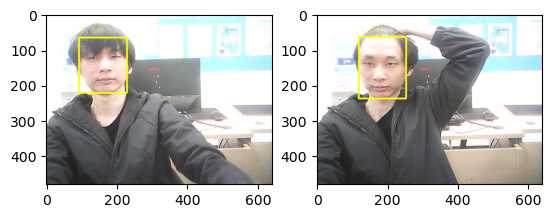

In [6]:
import matplotlib.pyplot as plt

for i in range(1,3):
    img = cv2.imread(f'./data/face_dt{i}.png')
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.subplot(1,2,i)
    plt.imshow(img)    

- 얼굴영역 자동 모자이크 처리하기(비식별화 처리기능 구현)

In [19]:
# openCV의 모자이크 기능
# 특정 영역의 주변 픽셀 정보의 변화에 따른 흐림 설정

img = cv2.imread('./data/TEAM3.png')
img_crop = img[ :100 , :100] #블러처리 할 부분 지정
img_blur = cv2.GaussianBlur(img_crop, ksize = (0,0), sigmaX = 13)
# ksize : 커널사이즈, 주변의 픽셀을 얼마나 참고해서 블러처리할건지
# sigmaX: 블러의 강도

img[ :100 , :100] = img_blur
cv2.imshow('img',img)

cv2.waitKey(0)
cv2.destroyAllWindows()

- 동영상에 블러처리하기

In [25]:
# 카메라기능 연결하고 윈도우창 띄우기

cap = cv2.VideoCapture(0)

color = [0,255,255]

line_th = 3 

cnt = 0

while True:
    try:
        ch, frame = cap.read() # ch: 성공여부, frame : 이미지
        flip_frame = cv2.flip(frame,1) #좌우 반전

        if not ch:
            print('동영상 재생 끝 or 읽기 실패')
            break

        faces, conf = cv.detect_face(flip_frame)
        for x,y,x2,y2 in faces:
            img_crop = flip_frame[y:y2 , x:x2]
            img_blur = cv2.GaussianBlur(img_crop, ksize = (0,0), sigmaX = 13)

            # 전체 이미지 특정 영역(y:y2 , x:x2)에 접근해서 블러처리 된 값을 대입
            flip_frame[y:y2 , x:x2] = img_blur
            
        cv2.imshow('video',flip_frame)
        key = cv2.waitKey(33)
        if key == ord('q'):
            print('사용자에 의해서 영상이 종료')
            break


        # 사진 캡쳐 기능
        if key == ord('w'):
            cnt += 1 
            print(f'./data/face_dt{cnt}.png 사진 저장')
            cv2.imwrite(f'./data/face_dt{cnt}.png',flip_frame, params = [cv2.IMWRITE_PNG_COMPRESSION, 0])

    except:
        print('카메라 읽기 실패 또는 영상 끝')
        cap.release()
        cv2.destroyAllWindows()


# break로 나갔을 경우

cap.release()
cv2.destroyAllWindows()

./data/face_dt1.png 사진 저장
./data/face_dt2.png 사진 저장
./data/face_dt3.png 사진 저장
카메라 읽기 실패 또는 영상 끝
동영상 재생 끝 or 읽기 실패


- 모자이크 처리하기

In [35]:
# 카메라기능 연결하고 윈도우창 띄우기

cap = cv2.VideoCapture(0)

color = [0,255,255]

line_th = 3 

cnt = 0

while True:
    try:
        ch, frame = cap.read() # ch: 성공여부, frame : 이미지
        flip_frame = cv2.flip(frame,1) #좌우 반전

        if not ch:
            print('동영상 재생 끝 or 읽기 실패')
            break


        faces, conf = cv.detect_face(flip_frame)
        for x,y,x2,y2 in faces:
            roi = flip_frame[y : y2 , x : x2 ]
            h, w = roi.shape[:2]

            mosaic_size = 10 # 모자이크 정도의 크기

            # 1. 작게 줄이기
            small = cv2.resize(roi, (mosaic_size,mosaic_size)) # 10,10 픽셀로 변환
            # 2. 다시 크게 늘리기(픽셀 깨짐 유지)
            mosaic = cv2.resize(small, (w,h),interpolation= cv2.INTER_NEAREST) #가장 가까운 픽셀 복사해서 빈공간 채우기
            # 3. 원본(flip_frame)에 덮어쓰기
            flip_frame[y:y2, x:x2] = mosaic
            
            
        cv2.imshow('video',flip_frame)
        key = cv2.waitKey(33)
        if key == ord('q'):
            print('사용자에 의해서 영상이 종료')
            break


        # 사진 캡쳐 기능
        if key == ord('w'):
            cnt += 1 
            print(f'./data/face_dt{cnt}.png 사진 저장')
            cv2.imwrite(f'./data/face_dt{cnt}.png',flip_frame, params = [cv2.IMWRITE_PNG_COMPRESSION, 0])

    except:
        print('카메라 읽기 실패 또는 영상 끝')
        cap.release()
        cv2.destroyAllWindows()


# break로 나갔을 경우

cap.release()
cv2.destroyAllWindows()

사용자에 의해서 영상이 종료
